In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
import math

from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import wandb

# **configurations**

In [ ]:
# from google.colab import drive
# drive.mount('/content/gdrive')

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("Ajhesh7/new-maths-tokenizer")
PAD_TOKEN = tokenizer.pad_token_id

In [ ]:
D_MODEL = 256                                                                                 # dimension of the model
D_FFNN = 4 * D_MODEL                                                                           # dimension of the FFNN
N_HEADS = 4                                                                                   # total attention head
N_DECODER_STACK = 16
VOCAB_SIZE = tokenizer.vocab_size                                                             # vocab's size
MAX_INPUT_TOKEN = 256
MAX_INFERENCE_LEN = 256
WANDB_LOGGIN_STEP = 500
EVAL_STEPS = 10_000
TEMPERATURE = 0.1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
assert D_MODEL % N_HEADS == 0, "D_MODEL must be divisible by N_HEADS"
D_HEAD = D_MODEL // N_HEADS                                                                   # dimension of the attn-head
LEARNING_RATE = 5e-4                                                                          # learning-rate
EPOCHS = 20
TRAIN_BATCH_SIZE = 56
EVAL_BATCH_SIZE = 6

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)
print(f"Random seed set to {SEED} for reproducibility.")

In [ ]:
tokenizer

In [ ]:
tokenizer.vocab_size

In [ ]:
def get_wandb_run():
  wandb.login(key=" ")
  run = wandb.init(
    entity="ajheshbasnet-kpriet",
    project="new-mathsGPT-kaggle",
    config={
        "D_MODEL": D_MODEL,
        "D_FFNN": D_FFNN,
        "N_HEADS": N_HEADS,
        "N_DECODER_STACK": N_DECODER_STACK,
        "VOCAB_SIZE": VOCAB_SIZE,
        "MAX_INPUT_TOKEN": MAX_INPUT_TOKEN,
        "MAX_INFERENCE_LEN": MAX_INFERENCE_LEN,
        "EVAL_STEPS": EVAL_STEPS,
        "TEMPERATURE": TEMPERATURE,
        "DEVICE": DEVICE,
        "D_HEAD": D_HEAD,
        "LEARNING_RATE": LEARNING_RATE,
        "EPOCHS": EPOCHS,
        "BATCH_SIZE": TRAIN_BATCH_SIZE
    },
  )
  return run

In [ ]:
class TokenEmbedding(nn.Module):

    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(VOCAB_SIZE, D_MODEL)

    def forward(self, x):
        return self.token_embedding(x)

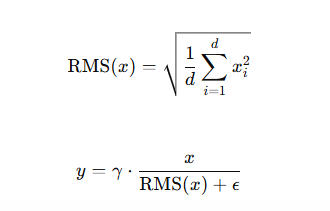

In [ ]:
class RMSNorm(nn.Module):

    def __init__(self):
      super().__init__()
      self.eps = 1e-9
      self.gamma = nn.Parameter(torch.ones(D_MODEL))

    def forward(self, x):   # [B, T, C]
      RMS_ = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True))
      return self.gamma * x / (RMS_ + self.eps)

In [ ]:
class RotaryPositionalEmbedding(nn.Module):

    def __init__(self):

        super().__init__()

        all_pos = torch.arange(0, MAX_INPUT_TOKEN)
        i = torch.arange(0, D_HEAD//2)
        inv_freq = 1.0 / (10000**((2*i)/D_HEAD))
        angle = all_pos.unsqueeze(-1)*inv_freq
        self.register_buffer("sin", torch.sin(angle))                                     # [ MAX_T , D_HEAD/2]
        self.register_buffer("cos", torch.cos(angle))                                     # [ MAX_T , D_HEAD/2]

    def forward(self, x, past_token = None):                                              #<-------- query / key !!

        B, H, T, C = x.size()

        if past_token is not None:
          chosen_id = past_token

        x = x.view(B, H, T, -1, 2)

        x1 = x[..., 0].clone()                                                           # [ H , T , D_HEAD]
        x2 = x[..., 1].clone()

        if past_token is None:
          sin = self.sin[:T, :].unsqueeze(0).unsqueeze(0)                                # [ T , D]--> [1, 1, T, D]
          cos = self.cos[:T, :].unsqueeze(0).unsqueeze(0)
        else:
          # In inference, chosen_id is the starting position (past_len), and T is the current sequence length.
          # For step-by-step generation, T is usually 1.
          # We need to slice T positional embeddings starting from chosen_id.
          sin = self.sin[chosen_id : chosen_id + T, :].unsqueeze(0).unsqueeze(0)        # [T_slice, D]--> [1, 1, T_slice, D]
          cos = self.cos[chosen_id : chosen_id + T, :].unsqueeze(0).unsqueeze(0)        # [T_slice, D]--> [1, 1, T_slice, D]

        assert sin.size(-2) == T, "the size of sin is not correct"
        assert cos.size(-2) == T, "the size of cos is not correct"

        x1_new = x1*cos - x2*sin
        x2_new = x1*sin + x2*cos

        x[..., 0] = x1_new
        x[..., 1] = x2_new

        x = x.view(B, H, T, -1)

        return x

In [ ]:
class AttentionHead(nn.Module):

    def __init__(self):
        super().__init__()

        self.q_mat = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.k_mat = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.v_mat = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.o_mat = nn.Linear(D_MODEL, D_MODEL, bias=False)

        self.register_buffer(
            'causal_mask',
            torch.tril(torch.ones(MAX_INPUT_TOKEN, MAX_INPUT_TOKEN)).bool()
        )

        self.RoPE = RotaryPositionalEmbedding()

        self.k_cache = None
        self.v_cache = None

        self.dropout = nn.Dropout(0.2)

    def reset_kv_cache(self):
        self.k_cache = None
        self.v_cache = None

    def forward(self, x, pad_mask, inference=False):

        B, T, C = x.size()

        # projections
        q = self.q_mat(x)
        k = self.k_mat(x)
        v = self.v_mat(x)

        # [B, T, C] → [B, heads, T, head_dim]
        q = q.view(B, T, N_HEADS, D_HEAD).permute(0, 2, 1, 3)
        k = k.view(B, T, N_HEADS, D_HEAD).permute(0, 2, 1, 3)
        v = v.view(B, T, N_HEADS, D_HEAD).permute(0, 2, 1, 3)

        # KV cache (UNCHANGED as requested)
        if inference:

            past_len = 0 if self.k_cache is None else self.k_cache.size(2)

            q = self.RoPE(q, past_len)
            k = self.RoPE(k, past_len)

            if self.k_cache is None:
              self.k_cache = k
              self.v_cache = v

            else:
              self.k_cache = torch.cat((self.k_cache, k), dim=2)    # type: ignore
              self.v_cache = torch.cat((self.v_cache, v), dim=2)    # type: ignore

            k = self.k_cache
            v = self.v_cache

        else:
            # RoPE
            q = self.RoPE(q)
            k = self.RoPE(k)

        T_q = q.size(2)
        T_k = k.size(2)

        # -----------------------
        # attention scores
        # -----------------------
        attn_score = (q @ k.transpose(-2, -1)) / math.sqrt(D_HEAD)

        # -----------------------
        # causal mask
        # -----------------------
        causal_mask = self.causal_mask[T_k - T_q : T_k, :T_k].to(q.device)  # [T_q, T_k]
        causal_mask = causal_mask[None, None, :, :]                           # [1, 1, T_q, T_k]

        # -----------------------
        # padding mask
        # pad_mask: [B, T]
        # -----------------------
        if inference:
            pad_mask = torch.ones(B, T_k, device=x.device, dtype=torch.bool)
        else:
            pad_mask = pad_mask[:, :T_k]

        pad_mask = pad_mask[:, None, None, :]

        # -----------------------
        # combine masks
        # -----------------------
        combined_mask = pad_mask & causal_mask                                # [B, 1, T_q, T_k]

        # apply mask
        attn_score = attn_score.masked_fill(~combined_mask, float('-inf'))

        # softmax
        attn_score = F.softmax(attn_score, dim=-1)
        attn_score = torch.nan_to_num(attn_score, nan=0.0)

        if not inference:
          attn_score = self.dropout(attn_score)

        # weighted sum
        attn_output = attn_score @ v   # [B, heads, T_q, head_dim]

        # merge heads
        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T_q, D_MODEL)

        # output projection
        attn_output = self.o_mat(attn_output)

        return attn_output

In [ ]:
sanity_attn_head = AttentionHead()
sanity_attn_head(torch.rand(1, 4, D_MODEL), torch.tensor([[1, 1, 0, 0]]).bool()).size()

In [ ]:
class SwigluFFNN(nn.Module):

    def __init__(self):

      super().__init__()

      self.wA = nn.Linear(D_MODEL, D_FFNN)
      self.wB = nn.Linear(D_MODEL, D_FFNN)
      self.wO = nn.Linear(D_FFNN, D_MODEL)

    def forward(self, x):

      a = self.wA(x)
      b = self.wB(x)
      SiLU_a = a * torch.sigmoid(a)
      h = SiLU_a * b
      o = self.wO(h)
      return o

In [ ]:
class OutputHead(nn.Module):

  def __init__(self):
    super().__init__()
    self.logits_head = nn.Linear(D_MODEL,  VOCAB_SIZE)

  def forward(self, x):
    return self.logits_head(x)

In [ ]:
class OneDecoderBlock(nn.Module):

  def __init__(self):

    super().__init__()
    self.RMSNorm1 = RMSNorm()
    self.RMSNorm2 = RMSNorm()
    self.AttentionHead = AttentionHead()
    self.swigLU = SwigluFFNN()

  def forward(self, x, pad_mask, inference=False):
    x = x + self.AttentionHead(self.RMSNorm1(x), pad_mask, inference)
    x = x + self.swigLU(self.RMSNorm2(x))
    return x

In [ ]:
class DECODER_STACK(nn.Module):

  def __init__(self):

    super().__init__()
    self.AllDecoderStack = nn.ModuleList([OneDecoderBlock() for _ in range(N_DECODER_STACK)])

  def forward(self, x, pad_mask, inference=False):

    for decoder in self.AllDecoderStack:
        x = decoder(x, pad_mask, inference)
    return x

In [ ]:
class mathGPT(nn.Module):

  def __init__(self):
    super().__init__()
    self.token_embedding = TokenEmbedding()
    self.RMSNorm = RMSNorm()
    self.decoder_stacks  = DECODER_STACK()
    self.logits_head = OutputHead()

    # Weight Tying
    self.logits_head.logits_head.weight = self.token_embedding.token_embedding.weight

    # Initialize weights
    self.apply(self._init_weights)

  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
      torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
      if module.bias is not None:
        torch.nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
      torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

  def forward(self,*, input_ids, attention_mask, inference = False):
    token_embed   = self.token_embedding(input_ids)
    hidden_states = self.decoder_stacks(token_embed, attention_mask, inference)
    norm_hidden_states = self.RMSNorm(hidden_states)
    logits = self.logits_head(norm_hidden_states)
    return logits

  def generate(self, *, input_ids, attention_mask, temperature = TEMPERATURE):

    self.eval()

    with torch.no_grad():

      for decoder_block in self.decoder_stacks.AllDecoderStack:
        decoder_block.AttentionHead.reset_kv_cache()

      ids = input_ids.clone()  # [B, T]
      msk = attention_mask.clone()

      GENERATE_INF_LEN = MAX_INFERENCE_LEN - input_ids.size(1)

      for _ in range(GENERATE_INF_LEN):
          logits = self(input_ids = input_ids, attention_mask = msk, inference = True)
          last_logit = logits[:, -1, :] / temperature
          probs = F.softmax(last_logit, dim=-1)
          tkn_id = torch.multinomial(probs, num_samples=1)
          # tkn_id = torch.argmax(probs, dim = -1)

          ids = torch.cat((ids, tkn_id), dim = -1)

          new_mask_value = (tkn_id != PAD_TOKEN).bool().to(msk.device)
          msk = torch.cat((msk, new_mask_value), dim = -1)

          input_ids = tkn_id

      return { "output_ids": ids, "attention_mask": msk }

In [ ]:
math_gpt = mathGPT().to(DEVICE)

In [ ]:
print(f'''<<< The total parameters are: >>> \n    {sum(p.numel() for p in math_gpt.parameters()) / 1e6 :.2f} million parameters.''')

print(f'\n<<< {DEVICE} is being used >>>')

# **training loops**

In [ ]:
def sanity_check():

  token_embedding = TokenEmbedding()
  swiglu_ffnn = SwigluFFNN()
  dec_stack = DECODER_STACK()

  check_RoPE = RotaryPositionalEmbedding()
  assert check_RoPE(torch.rand(2, 4, 8, D_HEAD)).size() == (2, 4, 8, D_HEAD)

  sanity_attn_head = AttentionHead()
  assert sanity_attn_head(torch.rand(1, 4, D_MODEL), torch.tensor([[1, 1, 0, 0]]).bool()).size() == (1, 4, D_MODEL)

  tok_ids = torch.tensor([[1, 2, 3, 4, 5]])

  assert token_embedding(tok_ids).size() == (1, 5, D_MODEL)
  assert swiglu_ffnn(torch.rand(1, 4, D_MODEL)).size() == (1, 4, D_MODEL)
  assert dec_stack(torch.rand(1, 4, D_MODEL), torch.tensor([[1, 1, 0, 0]]).bool()).size() == (1, 4, D_MODEL)

  odb = OneDecoderBlock()
  assert odb(torch.rand(1, 4, D_MODEL), torch.tensor([[1, 1, 0, 0]]).bool()).size() == (1, 4, D_MODEL)


  print("All sanity checks passed!🎉")

# **LOADING DATASETS**

In [ ]:
dataset = load_dataset("Ajhesh7/new-gsm8k-reasoning")

In [ ]:
int(len(dataset['train']) - len(dataset['train'])*0.05), int(len(dataset['train'])*0.05)

In [ ]:
dataset = dataset.shuffle(seed=42)

split = dataset['train'].train_test_split(test_size=0.05, seed=42)

train_dataset = split['train']
valid_dataset = split['test']

In [ ]:
tokenizer.unk_token_id, tokenizer.bos_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id

In [ ]:
print("Special Tokens Map:", tokenizer.special_tokens_map)
print("All Special Tokens:", tokenizer.all_special_tokens)

In [ ]:
train_dataset

In [ ]:
class DataPrep(Dataset):

    def __init__(self, dataset, tokenizer):
        super().__init__()
        self.dataset = dataset['text']
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        tok_ = self.tokenizer(self.dataset[idx], return_tensors='pt', max_length=MAX_INPUT_TOKEN+1, truncation=True, padding='max_length')
        ids = tok_['input_ids'].squeeze(0)
        msk = tok_['attention_mask'].squeeze(0)

        input_ids = ids[:-1]
        input_msk = msk[:-1]
        target_ids = ids[1:]

        return {
            "input_ids": input_ids,
            "attention_mask": input_msk,
            "target_ids": target_ids
        }

In [ ]:
train_dataset['text']

In [ ]:
train_data = DataPrep(train_dataset, tokenizer)
valid_data = DataPrep(valid_dataset, tokenizer)

In [ ]:
train_dataloader = DataLoader(train_data, shuffle=True, batch_size=TRAIN_BATCH_SIZE)
valid_dataloader = DataLoader(valid_data, shuffle=True, batch_size=EVAL_BATCH_SIZE)

In [ ]:
len(train_dataloader), len(valid_dataloader)

In [ ]:
def final_dry_run():
    print('--- Starting Logic Dry Run ---')
    # 1. Test Model Initialization
    test_model = mathGPT().to(DEVICE)
    test_optimizer = torch.optim.AdamW(test_model.parameters(), lr=1e-4)

    # 2. Create Dummy Batch
    # [Batch, Seq_len]
    dummy_input = torch.randint(0, VOCAB_SIZE, (2, 16)).to(DEVICE)
    dummy_mask = torch.ones((2, 16), dtype=torch.bool).to(DEVICE)
    dummy_targets = torch.randint(0, VOCAB_SIZE, (2, 16)).to(DEVICE)

    # 3. Forward Pass (Training Mode)
    test_model.train()
    logits = test_model(input_ids=dummy_input, attention_mask=dummy_mask, inference=False)
    print(f'Forward pass success. Logits shape: {logits.shape}')

    # 4. Loss and Backward Pass
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), dummy_targets.view(-1))
    loss.backward()
    print(f'Backward pass success. Loss: {loss.item():.4f}')

    # 5. Check Gradients
    has_grads = any(p.grad is not None for p in test_model.parameters())
    print(f'Gradients populated: {has_grads}')

    # 6. Test Inference (KV Cache & RoPE check)
    test_model.eval()
    # Generating 5 tokens
    gen_out = test_model.generate(input_ids=dummy_input[:, :5], attention_mask=dummy_mask[:, :5])
    print(f'Inference generation success. Output shape: {gen_out["output_ids"].shape}')

    print('\nStatus: All systems go! You are ready to train.')

final_dry_run()

In [ ]:
decay_params = []
no_decay_params = []

for name, param in math_gpt.named_parameters():
    if not param.requires_grad:
        continue

    if param.ndim >= 2:
        decay_params.append(param)      # weights
    else:
        no_decay_params.append(param)   # bias + norm

optimizer = torch.optim.AdamW(
    [
        {"params": decay_params, "weight_decay": 0.1},
        {"params": no_decay_params, "weight_decay": 0.0},
    ],
    lr=LEARNING_RATE,
    betas=(0.9, 0.95),
    eps=1e-8
)

In [ ]:
runs = get_wandb_run()

In [ ]:
import threading
import io
import torch
import math
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR, SequentialLR


In [ ]:
# --- Training setup ---
device_type = "cuda" if DEVICE == "cuda" else "cpu"
scaler = GradScaler(device="cuda") if device_type == "cuda" else None

total_steps = EPOCHS * len(train_dataloader)
warmup_steps = 0.01 * total_steps

warmup_scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda step: float(step) / float(max(1, warmup_steps))
)
cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=(total_steps - warmup_steps),
    eta_min=2.5e-5
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps]
)

global_step = 0
math_gpt.to(DEVICE)
CHECKPOINT_STEPS = 15000
running_loss = 0.0

# Google Drive save path
import os
CHECKPOINT_DIR = '/kaggle/working/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Starting training for {EPOCHS} epochs on {DEVICE} with Warmup-Cosine Schedule...")
print(f"Checkpoints will be saved to {CHECKPOINT_DIR}")

# --- Training loop ---
for epoch in range(EPOCHS):
    math_gpt.train()
    for batch_idx, batches in tqdm(
        enumerate(train_dataloader),
        total=len(train_dataloader),
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):
        input_ids = batches['input_ids'].to(DEVICE)
        attention_mask = batches['attention_mask'].to(DEVICE).bool()
        target_ids = batches['target_ids'].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device_type, enabled=(device_type=="cuda")):
            logits = math_gpt(input_ids=input_ids, attention_mask=attention_mask, inference=False)
            loss = F.cross_entropy(
                logits.reshape(-1, VOCAB_SIZE),
                target_ids.reshape(-1),
                ignore_index=PAD_TOKEN
            )

        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            total_norm = torch.nn.utils.clip_grad_norm_(math_gpt.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            total_norm = torch.nn.utils.clip_grad_norm_(math_gpt.parameters(), 1.0)
            optimizer.step()
            
        runs.log({"train-loss": loss.item()},  step=global_step)            

        scheduler.step()
        running_loss += loss.item()

        # --- Validation ---
        if global_step > 0 and global_step % EVAL_STEPS == 0:
            math_gpt.eval()
            valid_loss = 0.0
            with torch.no_grad():
                for valid_batches in valid_dataloader:
                    v_input_ids = valid_batches['input_ids'].to(DEVICE)
                    v_attention_mask = valid_batches['attention_mask'].to(DEVICE).bool()
                    v_target_ids = valid_batches['target_ids'].to(DEVICE)
                    with autocast(device_type=device_type, enabled=(device_type=="cuda")):
                        gpt_logits = math_gpt(input_ids=v_input_ids, attention_mask=v_attention_mask)
                        v_loss = F.cross_entropy(
                            gpt_logits.reshape(-1, VOCAB_SIZE),
                            v_target_ids.reshape(-1),
                            ignore_index=PAD_TOKEN
                        )
                    valid_loss += v_loss.item()
            avg_valid_loss = valid_loss / len(valid_dataloader)
            runs.log({
                "valid-loss": avg_valid_loss,
                "valid-perplexity": math.exp(avg_valid_loss),
            }, step=global_step)
            math_gpt.train()

        # # --- Checkpointing to Google Drive ---
        # if global_step > 0 and global_step % CHECKPOINT_STEPS == 0:
        #     checkpoint_path = os.path.join(CHECKPOINT_DIR, f"mathGPTckpt.pth")
        #     checkpoint_state = {
        #         "epoch": epoch,
        #         "global_step": global_step,
        #         "model_state_dict": math_gpt.state_dict(),
        #         "optimizer_state_dict": optimizer.state_dict(),
        #         "scheduler_state_dict": scheduler.state_dict(),
        #         "loss": loss.item()
        #     }
        #     torch.save(checkpoint_state, checkpoint_path)
        #     print(f"[Drive] Checkpoint saved to {checkpoint_path}")

        # --- Logging ---
        if global_step > 0 and global_step % WANDB_LOGGIN_STEP == 0:
            avg_loss = running_loss / WANDB_LOGGIN_STEP
            current_lr = scheduler.get_last_lr()[0]
            runs.log({
                "learning-rate": current_lr,
                "batch-train-loss": running_loss,
                "train-perplexity": math.exp(avg_loss),
                "gradient-norm": total_norm,
                "epoch": epoch,
                "step": global_step
            }, step=global_step)
            running_loss = 0.0

        global_step += 1

    # --- End-of-epoch model save to Google Drive ---
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pth")
    checkpoint_state = {
        "epoch": epoch,
        "global_step": global_step,
        "model_state_dict": math_gpt.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "loss": loss.item()
    }
    torch.save(checkpoint_state, checkpoint_path)
    print(f"[Drive] End-of-epoch checkpoint saved to {checkpoint_path}")

In [ ]:
load = torch.load("/kaggle/working/checkpoint_epoch_2.pth")

In [ ]:
math_gpt.load_state_dict(load['model_state_dict'])

In [ ]:
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pth")
    checkpoint_state = {
        # "epoch": epoch,
        # "global_step": global_step,
        "model_state_dict": math_gpt.state_dict(),
        # "optimizer_state_dict": optimizer.state_dict(),
        # "scheduler_state_dict": scheduler.state_dict(),
        # "loss": loss.item()
    }
    torch.save(checkpoint_state, checkpoint_path)
    print(f"Finally saved!!! {checkpoint_path}")

# **inference checking**

In [ ]:
def generate(*,input_ids, attention_mask, temperature = TEMPERATURE):

    math_gpt.eval()

    with torch.no_grad():

      for decoder_block in math_gpt.decoder_stacks.AllDecoderStack:
        decoder_block.AttentionHead.reset_kv_cache()

      ids = input_ids.clone()  # [B, T]
      msk = attention_mask.clone()

      GENERATE_INF_LEN = MAX_INFERENCE_LEN - input_ids.size(1)

      for _ in range(GENERATE_INF_LEN):
          logits = math_gpt(input_ids = input_ids, attention_mask = msk, inference = True)
          last_logit = logits[:, -1, :] / temperature
          probs = F.softmax(last_logit, dim=-1)
          tkn_id = torch.multinomial(probs, num_samples=1)
          # tkn_id = torch.argmax(probs, dim = -1).unsqueeze(0)

          ids = torch.cat((ids, tkn_id), dim = -1)

          new_mask_value = (tkn_id != PAD_TOKEN).bool().to(msk.device)
          msk = torch.cat((msk, new_mask_value), dim = -1)

          input_ids = tkn_id

      return { "output_ids": ids, "attention_mask": msk }

In [ ]:
# valid_dataset['text'][1500]
valid_dataset['text'][1500]

In [ ]:
import re

def print_output(txt: str):
    ids = tokenizer(txt, return_tensors='pt')['input_ids'].to(DEVICE)
    msk = tokenizer(txt, return_tensors='pt')['attention_mask'].to(DEVICE)
    o_ids=generate(input_ids=ids, attention_mask = msk)['output_ids']
    print(tokenizer.decode(o_ids)[0])

In [ ]:
text = valid_dataset['text'][8646]
print(text)

match = re.search(r'<question>.*?</question>', text, re.DOTALL)

if match:
    txt = match.group(0)
    print()
    print(txt)


print_output(txt)